<div style="background: linear-gradient(135deg, #1e293b 0%, #0f172a 100%); padding: 30px; border-radius: 8px; margin-bottom: 25px; box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.1);">
    <h1 style="color: #f8fafc; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-weight: 700; margin: 0; font-size: 2.2em; letter-spacing: -0.5px;"> Data panel PISA 2012-2022 🌍
</h1>
    <p style="color: #94a3b8; font-family: 'Segoe UI', sans-serif; margin: 8px 0 0 0; font-size: 1.1em;"> <i>Feature engenieering</i> & preparacion de datos
 </p>
    
</div>

<div style="
  background: linear-gradient(135deg, rgba(128, 128, 128, 0.25) 0%, rgba(64, 64, 64, 0.15) 100%);
  backdrop-filter: blur(4px);
  -webkit-backdrop-filter: blur(4px);
  border-left: 5px solid rgba(128, 128, 128, 0.6);
  padding: 16px;
  border-radius: 8px;
  color: inherit;
  margin: 20px 0;
">
  <strong style="display: block; margin-bottom: 6px; font-size: 1.1em;">
    ⚠️ Info del notebook
  </strong>
Para este notebook me estoy centrando en la tabla datos vertical (larga) con los datos de los estratos. Para utilizar los modelos de prediccion deberia tratarse la tabla ancha ( datos por pais ) y hacer la ingenieria de caracteristicas si fuese necesario.

</div>

# DataFrames de panel PISA y deberes

Se combinan las medias de las asignaturas con las variables de deberes por estrato y por pais.

In [ ]:
import pandas as pd
import gc
import sys
import os
from pathlib import Path
import pandas as pd
import gc
#Indicamos el workspace principal (dos niveles atrás)
sys.path.append(os.path.abspath('../../'))


from src.utils_pisa import *


%load_ext autoreload
%autoreload 2


ruta_datos_procesados = Path('../../data/processed')

establecer_semilla(42)
pd.set_option('display.float_format', lambda valor: f'{valor:.2f}')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Semillas del proyecto establecidas con éxito (seed=42).


In [106]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

## Panel por pais y estrato

La union usa `CNT`, `STRATUM` y `year` para asociar las observaciones del mismo pais, estrato y edicion.

In [107]:
df_medias_estrato = pd.read_parquet(
    ruta_datos_procesados / 'pisa_medias_asignaturas_estrato_anual.parquet'
)
df_deberes_strat = pd.read_parquet(
    ruta_datos_procesados / 'deberes_strat.parquet'
)

df_panel_estrato = df_medias_estrato.merge(
    df_deberes_strat,
    on=['CNT', 'STRATUM', 'year'],
    how='inner',
    validate='one_to_one',
)
df_panel_estrato = df_panel_estrato[
    ['CNT', 'STRATUM', 'year']
    + [col for col in df_panel_estrato.columns if col not in ['CNT', 'STRATUM', 'year']]
]

display(df_panel_estrato.head())
print(f'Dimensiones del panel por estrato: {df_panel_estrato.shape}')

,CNT,STRATUM,year,media_math_estrato,media_read_estrato,media_scie_estrato,tiempo_deberes_totales_diarios,dispone_personal_apoyo
0,USA,USA08,2022,476.10,520.35,512.01,3.07,1.00
1,USA,USA07,2022,539.40,535.90,592.47,3.40,NaN
2,USA,USA06,2022,454.64,493.90,490.45,2.55,1.07
3,USA,USA05,2022,476.43,507.31,490.59,3.05,1.00
4,USA,USA04,2022,469.99,503.32,504.79,2.60,1.09


Dimensiones del panel por estrato: (2328, 8)


## Panel por pais

La union usa `CNT` y `year` para asociar las observaciones del mismo pais y edicion.

In [108]:
df_medias_pais = pd.read_parquet(
    ruta_datos_procesados / 'pisa_medias_asignaturas_pais_anual.parquet'
)
df_deberes_cnt = pd.read_parquet(
    ruta_datos_procesados/ 'deberes_cnt.parquet'
)

df_panel_pais = df_medias_pais.merge(
    df_deberes_cnt,
    on=['CNT', 'year'],
    how='inner',
    validate='one_to_one',
)
df_panel_pais = df_panel_pais[
    ['CNT', 'year']
    + [col for col in df_panel_pais.columns if col not in ['CNT', 'year']]
]

display(df_panel_pais.head())
print(f'Dimensiones del panel por pais: {df_panel_pais.shape}')

,CNT,year,media_math_pais,media_read_pais,media_scie_pais,tiempo_deberes_totales_diarios,dispone_personal_apoyo
0,USA,2022,464.89,503.94,499.41,2.73,1.05
1,TUR,2022,453.15,456.08,475.94,3.14,1.62
2,SWE,2022,481.77,486.98,493.55,2.44,1.07
3,SVN,2022,484.53,468.54,499.96,2.44,1.54
4,SVK,2022,463.99,446.86,462.27,2.35,1.30


Dimensiones del panel por pais: (132, 7)


---

# AGREGACION DE LOS **DATOS ECONOMICOS SIMULADOS**

In [109]:
ruta_datos_simulados = Path('../../notebooks/fase_2_feature_engineering')
#pisa_datos_economicos_simulados

In [110]:
def ordenar_columnas_panel(df):
    claves = [col for col in ['CNT', 'STRATUM', 'year'] if col in df.columns]
    medias = [
        col for col in [
            'media_math_pais', 'media_read_pais', 'media_scie_pais',
            'media_math_estrato', 'media_read_estrato', 'media_scie_estrato',
        ]
        if col in df.columns
    ]
    resto = [col for col in df.columns if col not in claves + medias]
    return df[claves + medias + resto]


# Paneles en formato largo
df_panel_estrato = ordenar_columnas_panel(df_panel_estrato)
df_panel_estrato_final = ordenar_columnas_panel(df_panel_estrato_final)
df_panel_pais = ordenar_columnas_panel(df_panel_pais)
df_pais_transaccional = ordenar_columnas_panel(df_pais_transaccional)


# Panel por país en formato ancho: medias primero, agrupadas por asignatura
if 'df_pais_ancho' in globals():
    orden_medias = [
        col
        for prefijo in ['media_math_pais_', 'media_read_pais_', 'media_scie_pais_']
        for col in df_pais_ancho.columns
        if col.startswith(prefijo)
    ]
    claves = ['CNT'] if 'CNT' in df_pais_ancho.columns else []
    resto = [
        col for col in df_pais_ancho.columns
        if col not in claves + orden_medias
    ]
    df_pais_ancho = df_pais_ancho[claves + orden_medias + resto]

In [79]:
# ... [Tu código actual que genera df_panel_estrato y df_panel_pais] ...

# =====================================================================
# INTEGRACIÓN Y PIVOTADO DE VARIABLES ECONÓMICAS ALEATORIAS
# =====================================================================

# 1. Leemos el archivo parquet base aleatorio
df_macro_base = pd.read_parquet(ruta_datos_simulados/ 'pisa_datos_economicos_simulados.parquet')

# Aseguramos tipos uniformes para los cruces
df_macro_base['year'] = df_macro_base['year'].astype(int)
df_panel_estrato['year'] = df_panel_estrato['year'].astype(int)
df_panel_pais['year'] = df_panel_pais['year'].astype(int)


# ---------------------------------------------------------------------
# UNIÓN A: TABLA LARGA POR ESTRATOS (Formato transaccional para modelos)
# ---------------------------------------------------------------------
df_panel_estrato_final = df_panel_estrato.merge(
    df_macro_base,
    on=['CNT', 'year'],
    how='inner'
)

columnas_macro = ['PIB_per_capita_PPP', 'Gasto_Alumno_PPP', 'Gasto_Educacion_PIB', 'Indice_Gini', 'ESCS_media_pais_anual']
df_panel_estrato_final = df_panel_estrato_final[[col for col in df_panel_estrato_final.columns if col not in [['CNT', 'STRATUM', 'year']]+ columnas_macro]+ columnas_macro
]

print("=== 1. PANEL POR ESTRATO FINAL COMPLETO (TABLA LARGA) ===")
display(df_panel_estrato_final.head())
print(f'Dimensiones del panel largo: {df_panel_estrato_final.shape}\n')


=== 1. PANEL POR ESTRATO FINAL COMPLETO (TABLA LARGA) ===


,CNT,STRATUM,year,media_math_estrato,media_read_estrato,media_scie_estrato,tiempo_deberes_totales_diarios,dispone_personal_apoyo,PIB_per_capita_PPP,Gasto_Alumno_PPP,Gasto_Educacion_PIB,Indice_Gini,ESCS_media_pais_anual
0,USA,USA08,2022,476.10,520.35,512.01,3.07,1.00,24568.52,56890.87,4.63,39.15,0.21
1,USA,USA07,2022,539.40,535.90,592.47,3.40,NaN,24568.52,56890.87,4.63,39.15,0.21
2,USA,USA06,2022,454.64,493.90,490.45,2.55,1.07,24568.52,56890.87,4.63,39.15,0.21
3,USA,USA05,2022,476.43,507.31,490.59,3.05,1.00,24568.52,56890.87,4.63,39.15,0.21
4,USA,USA04,2022,469.99,503.32,504.79,2.60,1.09,24568.52,56890.87,4.63,39.15,0.21


Dimensiones del panel largo: (2328, 13)



In [80]:
# ---------------------------------------------------------------------
# UNIÓN B: TABLA POR PAÍS 
# ---------------------------------------------------------------------
# Primero unimos tus datos de df_panel_pais con la matriz macro base
df_pais_transaccional = df_panel_pais.merge(
    df_macro_base,
    on=['CNT', 'year'],
    how='inner'
)

# Identificamos todas las columnas que queremos pivotar (las tuyas originales + las nuevas económicas)
columnas_a_pivotar = [col for col in df_pais_transaccional.columns if col not in ['CNT', 'year']]

# Aplicamos tu lógica exacta: pivotamos para que los países sean filas y los años columnas
df_pais_ancho = df_pais_transaccional.pivot(
    index='CNT',
    columns='year',
    values=columnas_a_pivotar
)

# Aplanamos el nivel de las columnas para que quede limpio de leer (ej: PIB_per_capita_PPP_2022)
df_pais_ancho.columns = [f'{var}_{anio}' for var, anio in df_pais_ancho.columns]
df_pais_ancho = df_pais_ancho.reset_index()

print("=== 2. PANEL POR PAÍS FINAL COMPLETO (FORMATO ANCHO PIVOTADO) ===")
display(df_pais_ancho.head())
print(f'Dimensiones del panel ancho: {df_pais_ancho.shape}')

=== 2. PANEL POR PAÍS FINAL COMPLETO (FORMATO ANCHO PIVOTADO) ===


,CNT,media_math_pais_2012,media_math_pais_2015,media_math_pais_2018,media_math_pais_2022,media_read_pais_2012,media_read_pais_2015,media_read_pais_2018,media_read_pais_2022,media_scie_pais_2012,...,Gasto_Educacion_PIB_2018,Gasto_Educacion_PIB_2022,Indice_Gini_2012,Indice_Gini_2015,Indice_Gini_2018,Indice_Gini_2022,ESCS_media_pais_anual_2012,ESCS_media_pais_anual_2015,ESCS_media_pais_anual_2018,ESCS_media_pais_anual_2022
0,AUS,504.15,493.90,491.36,487.08,511.80,502.90,502.63,498.05,521.49,...,6.75,5.36,37.97,38.03,28.31,33.80,-1.03,0.62,-0.95,-0.63
1,AUT,505.54,496.74,498.94,487.27,489.61,484.87,484.39,480.41,505.78,...,3.29,3.44,32.16,37.81,46.72,40.11,-0.13,-1.36,1.40,-0.18
2,BEL,514.53,506.98,508.07,489.49,508.62,498.52,492.86,478.85,504.87,...,7.23,3.88,45.73,36.67,45.37,24.13,-0.72,-0.95,0.29,-0.52
3,CAN,518.07,515.65,512.02,496.95,523.12,526.67,520.09,507.13,525.44,...,3.02,3.33,31.92,24.86,43.39,31.96,-0.66,1.46,0.62,-1.15
4,CHE,530.93,521.25,515.31,507.99,509.04,492.20,483.93,483.33,515.30,...,6.42,4.92,24.59,45.18,37.03,23.64,-0.57,-0.08,0.81,-1.18


Dimensiones del panel ancho: (33, 41)



---


In [81]:
df_panel_estrato_final.columns

Index(['CNT', 'STRATUM', 'year', 'media_math_estrato', 'media_read_estrato',
       'media_scie_estrato', 'tiempo_deberes_totales_diarios',
       'dispone_personal_apoyo', 'PIB_per_capita_PPP', 'Gasto_Alumno_PPP',
       'Gasto_Educacion_PIB', 'Indice_Gini', 'ESCS_media_pais_anual'],
      dtype='str')

# *Feature engenieering*

## Calculo de la presión académica


Para evaluar el impacto real de la carga de trabajo en casa, se crea una nueva métrica continua denominada **Presión Académica Neta**. Esta variable relaciona directamente la cantidad de deberes con los recursos de apoyo que ofrece el centro escolar, bajo la premisa de que el apoyo reduce la carga escolar

**Fórmula:**
$$Presion\_Academica\_Neta = \frac{tiempo\_deberes\_totales\_diarios}{1 + dispone\_personal\_apoyo}$$

** Denominador ($1 + apoyo$):**
 (Efecto amortiguador):** El denominador actúa como un divisor de la carga de trabajo. 
  * Si el colegio **no tiene apoyo** (0), el denominador es $1 + 0 = 1$. El alumno absorbe el 100% de la carga de los deberes.
  * Si el colegio **sí tiene apoyo** (1), el denominador es $1 + 1 = 2$. La presión neta se reduce a la mitad, reflejando cómo los profesores de refuerzo alivian el esfuerzo solitario en casa.

In [82]:
df_panel_estrato_final['Presion_Academica_Neta'] = df_panel_estrato_final['tiempo_deberes_totales_diarios'] / (1 + df_panel_estrato_final['dispone_personal_apoyo'])

In [83]:
df_panel_estrato_final['Presion_Academica_Neta'].describe()

count   1944.00
mean       1.19
std        0.52
min        0.00
25%        0.86
50%        1.11
75%        1.41
max        6.70
Name: Presion_Academica_Neta, dtype: float64

## Discretización del Nivel Socioeconómico (ECS)



Se transforma el índice continuo de estatus socioeconómico (`ECS_nivel`) en una variable categórica ordinal. De tal forma que se analice el impacto de las variables educativas a través de un indice cualitativo mas intuitivo

**Regla de codificación:**
Se utiliza una discretización basada en cuantiles para dividir los estratos en tres grupos. De esta forma se pueden aprender patrones de cada grupo social

* **Bajo:** menor índice socioeconómico.
* **Medio:** punto intermedio del cuantil.
* **Alto:** mayor índice socioeconómico.

Esta segmentación permitirá evaluar interacciones complejas, como por ejemplo, si la *Presión Académica Neta* tiene un efecto dispar en el rendimiento dependiendo de los recursos del hogar y del entorno del estrato.

In [84]:
# Etiquetas para los 3 niveles
etiquetas_socioeconomicas = ['Bajo', 'Medio', 'Alto']

# Dividimos la variable continua en 3 partes iguales ( q=3 )
df_panel_estrato_final['ECS_categoria'] = pd.qcut(
    df_panel_estrato_final['ESCS_media_pais_anual'], 
    q=3, 
    labels=etiquetas_socioeconomicas
)

# Visualizamos cómo ha quedado el reparto de estratos por cada nivel
print("Porcentaje de distribución de estratos por nivel socioeconómico:")
print(df_panel_estrato_final['ECS_categoria'].value_counts(normalize=True) * 100)

Porcentaje de distribución de estratos por nivel socioeconómico:
ECS_categoria
Medio   36.94
Bajo    33.33
Alto    29.73
Name: proportion, dtype: float64


<div style="
  background: linear-gradient(135deg, rgba(128, 128, 128, 0.25) 0%, rgba(64, 64, 64, 0.15) 100%);
  backdrop-filter: blur(4px);
  -webkit-backdrop-filter: blur(4px);
  border-left: 5px solid rgba(128, 128, 128, 0.6);
  padding: 16px;
  border-radius: 8px;
  color: inherit;
  margin: 20px 0;
">
  <strong style="display: block; margin-bottom: 6px; font-size: 1.1em;">
    💡 Division a nivel global
  </strong>
    El código anterior calcula los terciles de forma global (comparando todos los estratos de todos los países a la vez). Si en tu investigación prefieres que un estrato se considere "Alto" o "Bajo" en relación a su propio país (lo cual a veces es más preciso en estudios internacionales). Se debe aaplicar el qcut agrupando por país ('CNT')

</div>

## Perfil Macroeconómico



Para dotar al modelo de un contexto estructural simplificado, se segmentan los países en perfiles macroeconómicos utilizando un algoritmo no supervisado (K-Means). 

**Metodología:**
1. Se aísla un *dataframe* transversal a nivel de país con los indicadores estructurales: `PIB_per_capita_PPP`, `Gasto_Alumno_PPP`, `Gasto_Educacion_PIB` e `Indice_Gini`.
    * Creamos la "foto fija" de la década para cada país
    * Calcular la media de la década elimina el "ruido" de posibles picos o caídas puntuales en un año concreto y captura el verdadero modelo socioeconómico del país

2. Se escalan las variables (StandardScaler) para evitar que magnitudes como el PIB dominen el cálculo de distancias sobre porcentajes como el Gini.
3. Se entrena un modelo K-Means (previa evaluación del número óptimo de clústeres mediante el método del codo o silueta, asumiendo aquí $k=3$ o $k=4$).
4. Se asigna la etiqueta resultante (`Perfil_Pais`) a la tabla longitudinal larga, mapeando cada estrato a la realidad estructural de su nación.

In [85]:
# Asumimos que los datos macro son relativamente estables o usamos la media de la década por país
variables_macro = ['PIB_per_capita_PPP', 'Gasto_Alumno_PPP', 'Gasto_Educacion_PIB', 'Indice_Gini', 'ESCS_media_pais_anual']
df_macro_pais = df_panel_estrato_final.groupby('CNT')[variables_macro].mean().dropna()

Mediante el `StandardScaler` transformamos los datos de cada columna para que adopten una distribución normal estándar ( media en 0 y desviacion 1)

Se obliga así al modelo a darle la misma importancia a cada variable. Esto es, las variaciones de las variables se encuentran en el mismo rango dado que K-means es muy sensible a las magnitudes

In [86]:
#Instanciamos el estandar scaler
scaler = StandardScaler()

#transformamos los datos
datos_macro_escalados = scaler.fit_transform(df_macro_pais)

### Analisis de datos para clustering

In [87]:
#Calculo de los modelos
inercias = []
siluetas = []

rango_k = range(2, 9) # Evaluamos desde 2 hasta 8 clústeres

# Bucle para probar diferentes valores de agrupaciones
for k in rango_k:
    modelo_k = KMeans(n_clusters=k, random_state=42, n_init='auto')
    etiquetas = modelo_k.fit_predict(datos_macro_escalados)
    
    inercias.append(modelo_k.inertia_)
    siluetas.append(silhouette_score(datos_macro_escalados, etiquetas))

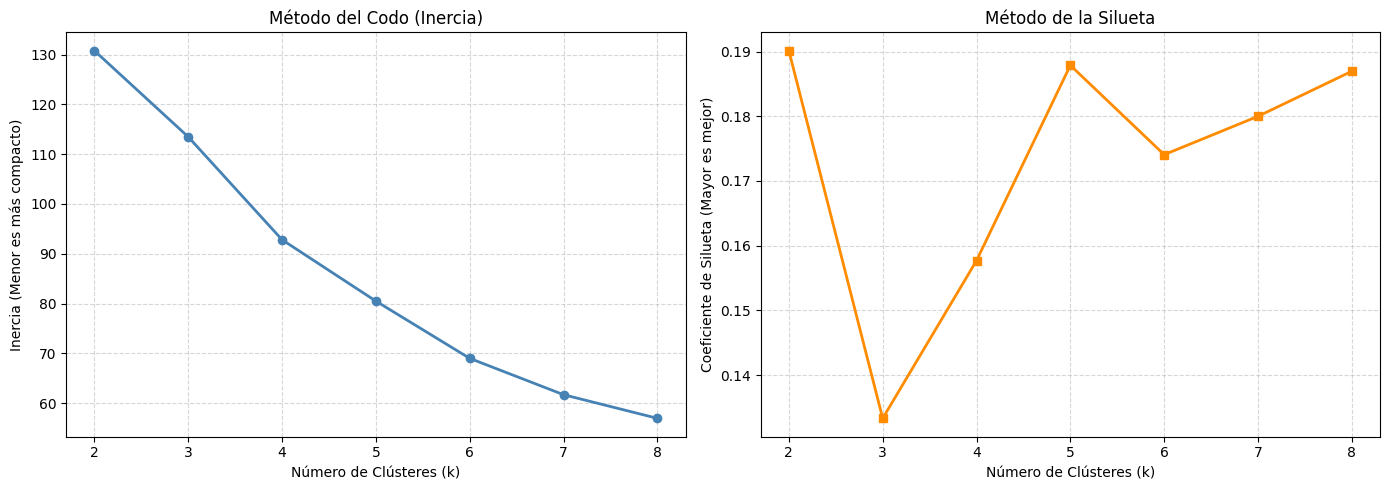

In [88]:


# Configuración de la figura con dos gráficos en paralelo
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico del Método del Codo
ax[0].plot(rango_k, inercias, marker='o', color='steelblue', linewidth=2)
ax[0].set_title('Método del Codo (Inercia)')
ax[0].set_xlabel('Número de Clústeres (k)')
ax[0].set_ylabel('Inercia (Menor es más compacto)')
ax[0].grid(True, linestyle='--', alpha=0.5)

# Gráfico del Método de la Silueta
ax[1].plot(rango_k, siluetas, marker='s', color='darkorange', linewidth=2)
ax[1].set_title('Método de la Silueta')
ax[1].set_xlabel('Número de Clústeres (k)')
ax[1].set_ylabel('Coeficiente de Silueta (Mayor es mejor)')
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**NÚMERO OPTIMO**: K=4

* **Método de la Silueta**: Muestra un pico muy claro y alto exactamente en $k=5$, casi rozando el máximo absoluto que se da en $k=2$. Elegir $k=2$ dividiría los países simplemente en dos bloques (probablemente renta alta vs. renta media/baja), lo cual es demasiado binario. El pico en $k=5$ garantizaRÍA grupos internamente cohesionados pero con suficientes matices.   

* **Método del Codo** : Aunque la curva desciende de forma bastante continua, es a partir de $k=4$ y $k=5$ donde la pendiente empieza a perder fuerza, indicando que añadir un sexto o séptimo grupo ya no aporta una mejora drástica en la compacidad de los clústeres.

In [89]:
#Entrenamos el modelo final en función del numero de clusters encontrados

kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
df_macro_pais['Perfil_Pais'] = kmeans.fit_predict(datos_macro_escalados)

In [90]:
display(df_macro_pais.groupby('Perfil_Pais')[variables_macro].mean())

# Vemos qué países caen en cada uno para confirmar
paises_por_cluster = df_macro_pais.groupby('Perfil_Pais').apply(
    lambda x: ', '.join(x.index)
).reset_index(name='Paises_Incluidos')
display(paises_por_cluster)

,PIB_per_capita_PPP,Gasto_Alumno_PPP,Gasto_Educacion_PIB,Indice_Gini,ESCS_media_pais_anual
Perfil_Pais,,,,,
0,52138.69,102823.12,6.22,36.22,-0.38
1,50631.59,89737.05,4.75,32.21,-0.19
2,59194.44,60983.11,4.81,36.71,0.24
3,39159.56,93573.38,5.34,41.29,0.22


,Perfil_Pais,Paises_Incluidos
0,0,"AUS, ESP, FRA, GBR, KOR, POL"
1,1,"BEL, CHE, CZE, DEU, DNK, FIN, GRC, IRL, ISL, M..."
2,2,"AUT, CAN, EST, HUN, NOR, PRT, SVK"
3,3,"CHL, ISR, ITA, JPN, NLD, NZL, USA"


**Explicacion de los grupos** :
Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.
Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.


In [91]:
mapa_nombres = {
    0: "Alto Esfuerzo Educ_Bajo ESCS",
    1: "Modelo Igualitario_Inversión Mod.",
    2: "Alta Renta_Bajo Gasto Alumno",
    3: "Emergente_Alta Desigualdad",
}
df_macro_pais['Perfil_Pais'] = df_macro_pais['Perfil_Pais'].map(mapa_nombres)

### Representacion PCA

In [92]:
#Aplicamos el PCA y reducimos el numero de variables a 2 componentes 
pca = PCA(n_components=2)
componentes_pca = pca.fit_transform(datos_macro_escalados)

df_macro_pais['PCA_1'] = componentes_pca[:, 0]
df_macro_pais['PCA_2'] = componentes_pca[:, 1]

# Extraemos el % de información que contiene cada componente
var_exp = pca.explained_variance_ratio_ * 100

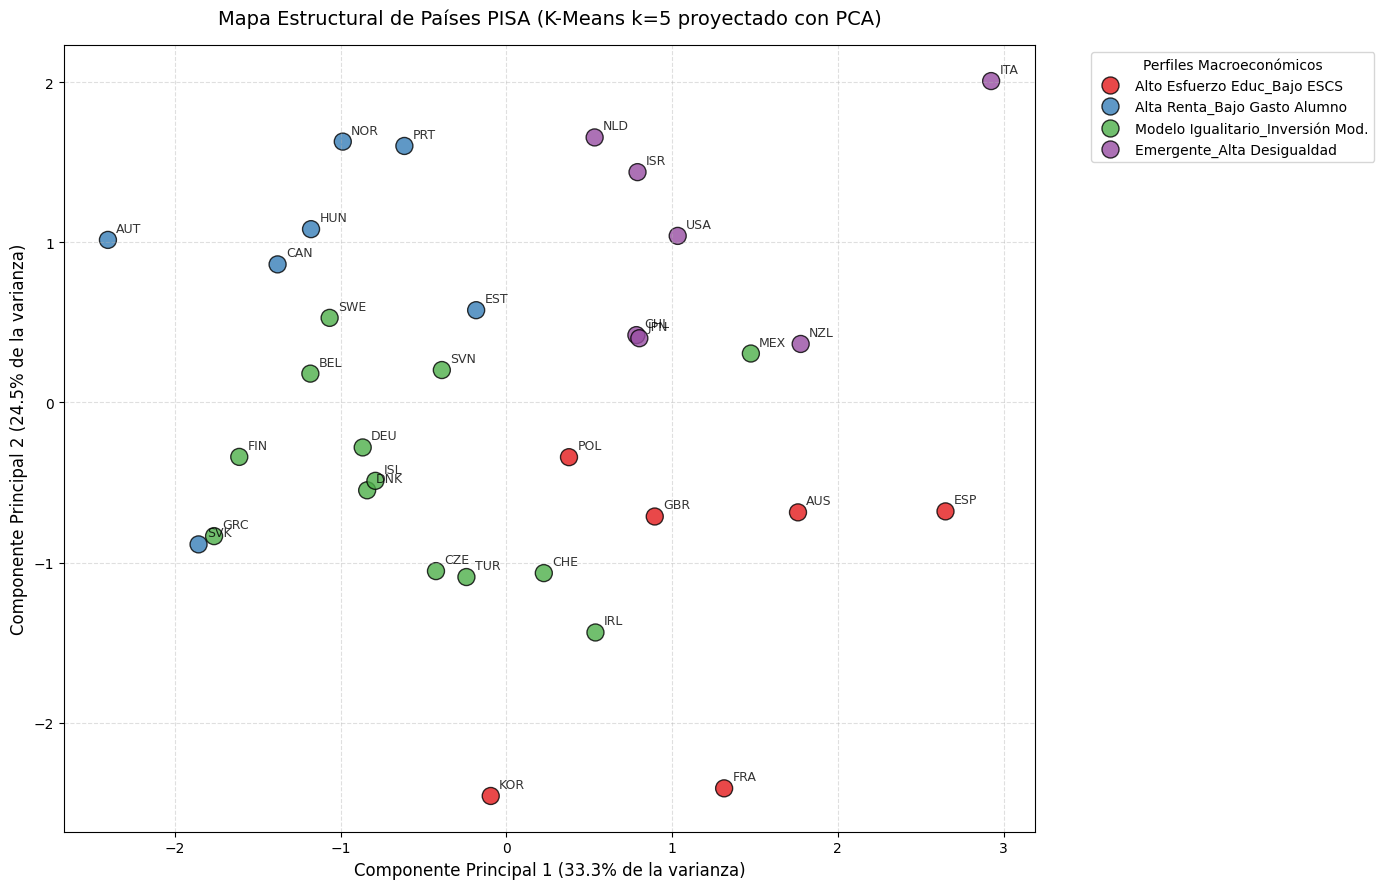

Varianza total explicada por las 2 dimensiones: 57.8%


In [93]:
# Dibujamos el scatter plot
plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=df_macro_pais,
    x='PCA_1', 
    y='PCA_2',
    hue='Perfil_Pais', 
    palette='Set1', 
    s=150,          
    edgecolor='black',
    alpha=0.8
)

# Se añade el código del PAIS
for i, pais in enumerate(df_macro_pais.index):
    plt.annotate(
        pais, 
        (df_macro_pais['PCA_1'].iloc[i] + 0.05, df_macro_pais['PCA_2'].iloc[i] + 0.05),
        fontsize=9,
        alpha=0.8
    )

# Formato estético del gráfico
plt.title('Mapa Estructural de Países PISA (K-Means k=5 proyectado con PCA)', fontsize=14, pad=15)
plt.xlabel(f'Componente Principal 1 ({var_exp[0]:.1f}% de la varianza)', fontsize=12)
plt.ylabel(f'Componente Principal 2 ({var_exp[1]:.1f}% de la varianza)', fontsize=12)
plt.legend(title='Perfiles Macroeconómicos', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 4. Mostrar varianza total conservada
print(f"Varianza total explicada por las 2 dimensiones: {var_exp.sum():.1f}%")

In [94]:

# Cruzamos la etiqueta con el panel original
df_panel_estrato_final = df_panel_estrato_final.merge(
    df_macro_pais[['Perfil_Pais']], 
    on='CNT', 
    how='left'
)

# Preparacion de datos para modelo

In [95]:
#Estado del panel de datos por estrato despues de la ingenieria de características
df_panel_estrato_final.head()

,CNT,STRATUM,year,media_math_estrato,media_read_estrato,media_scie_estrato,tiempo_deberes_totales_diarios,dispone_personal_apoyo,PIB_per_capita_PPP,Gasto_Alumno_PPP,Gasto_Educacion_PIB,Indice_Gini,ESCS_media_pais_anual,Presion_Academica_Neta,ECS_categoria,Perfil_Pais
0,USA,USA08,2022,476.10,520.35,512.01,3.07,1.00,24568.52,56890.87,4.63,39.15,0.21,1.53,Medio,Emergente_Alta Desigualdad
1,USA,USA07,2022,539.40,535.90,592.47,3.40,NaN,24568.52,56890.87,4.63,39.15,0.21,NaN,Medio,Emergente_Alta Desigualdad
2,USA,USA06,2022,454.64,493.90,490.45,2.55,1.07,24568.52,56890.87,4.63,39.15,0.21,1.23,Medio,Emergente_Alta Desigualdad
3,USA,USA05,2022,476.43,507.31,490.59,3.05,1.00,24568.52,56890.87,4.63,39.15,0.21,1.53,Medio,Emergente_Alta Desigualdad
4,USA,USA04,2022,469.99,503.32,504.79,2.60,1.09,24568.52,56890.87,4.63,39.15,0.21,1.24,Medio,Emergente_Alta Desigualdad


In [96]:
df_panel_estrato_final.columns

Index(['CNT', 'STRATUM', 'year', 'media_math_estrato', 'media_read_estrato',
       'media_scie_estrato', 'tiempo_deberes_totales_diarios',
       'dispone_personal_apoyo', 'PIB_per_capita_PPP', 'Gasto_Alumno_PPP',
       'Gasto_Educacion_PIB', 'Indice_Gini', 'ESCS_media_pais_anual',
       'Presion_Academica_Neta', 'ECS_categoria', 'Perfil_Pais'],
      dtype='str')

## *One-Hot Encoding* para variables categóricas

Aplicamos *one-hot encoding* para las variables categoricas* : ECS_categoría y perfil_pais

In [99]:
from sklearn.preprocessing import OneHotEncoder


#Inicializamos el codificador
encoder = OneHotEncoder(sparse_output=False, drop='first')

# Definimos las columnas a codificar
columnas_categoricas = ['ECS_categoria', 'Perfil_Pais']

# Ajustamos y transformamos los datos 
encoded_data = encoder.fit_transform(df_panel_estrato_final[columnas_categoricas])

# Crear un nuevo DataFrame con las columnas codificadas usando los nombres generados
df_categorias_encoded = pd.DataFrame(
    encoded_data, 
    columns=encoder.get_feature_names_out(columnas_categoricas),
    index=df_panel_estrato_final.index
)

# Unir el resultado con el DataFrame original y eliminar las columnas categóricas antiguas
df_modelo_estrato = pd.concat([df_panel_estrato_final.drop(columns=columnas_categoricas), df_categorias_encoded], axis=1)

In [100]:
df_modelo_estrato.head()

,CNT,STRATUM,year,media_math_estrato,media_read_estrato,media_scie_estrato,tiempo_deberes_totales_diarios,dispone_personal_apoyo,PIB_per_capita_PPP,Gasto_Alumno_PPP,Gasto_Educacion_PIB,Indice_Gini,ESCS_media_pais_anual,Presion_Academica_Neta,ECS_categoria_Bajo,ECS_categoria_Medio,Perfil_Pais_Alto Esfuerzo Educ_Bajo ESCS,Perfil_Pais_Emergente_Alta Desigualdad,Perfil_Pais_Modelo Igualitario_Inversión Mod.
0,USA,USA08,2022,476.10,520.35,512.01,3.07,1.00,24568.52,56890.87,4.63,39.15,0.21,1.53,0.00,1.00,0.00,1.00,0.00
1,USA,USA07,2022,539.40,535.90,592.47,3.40,NaN,24568.52,56890.87,4.63,39.15,0.21,NaN,0.00,1.00,0.00,1.00,0.00
2,USA,USA06,2022,454.64,493.90,490.45,2.55,1.07,24568.52,56890.87,4.63,39.15,0.21,1.23,0.00,1.00,0.00,1.00,0.00
3,USA,USA05,2022,476.43,507.31,490.59,3.05,1.00,24568.52,56890.87,4.63,39.15,0.21,1.53,0.00,1.00,0.00,1.00,0.00
4,USA,USA04,2022,469.99,503.32,504.79,2.60,1.09,24568.52,56890.87,4.63,39.15,0.21,1.24,0.00,1.00,0.00,1.00,0.00


In [101]:
df_modelo_estrato.columns


Index(['CNT', 'STRATUM', 'year', 'media_math_estrato', 'media_read_estrato',
       'media_scie_estrato', 'tiempo_deberes_totales_diarios',
       'dispone_personal_apoyo', 'PIB_per_capita_PPP', 'Gasto_Alumno_PPP',
       'Gasto_Educacion_PIB', 'Indice_Gini', 'ESCS_media_pais_anual',
       'Presion_Academica_Neta', 'ECS_categoria_Bajo', 'ECS_categoria_Medio',
       'Perfil_Pais_Alto Esfuerzo Educ_Bajo ESCS',
       'Perfil_Pais_Emergente_Alta Desigualdad',
       'Perfil_Pais_Modelo Igualitario_Inversión Mod.'],
      dtype='str')

In [102]:
df_modelo_estrato = df_modelo_estrato.drop(columns=['CNT','STRATUM'])

# Almacenamiento de los datos preparados

In [103]:
df_modelo_estrato.head()

,year,media_math_estrato,media_read_estrato,media_scie_estrato,tiempo_deberes_totales_diarios,dispone_personal_apoyo,PIB_per_capita_PPP,Gasto_Alumno_PPP,Gasto_Educacion_PIB,Indice_Gini,ESCS_media_pais_anual,Presion_Academica_Neta,ECS_categoria_Bajo,ECS_categoria_Medio,Perfil_Pais_Alto Esfuerzo Educ_Bajo ESCS,Perfil_Pais_Emergente_Alta Desigualdad,Perfil_Pais_Modelo Igualitario_Inversión Mod.
0,2022,476.10,520.35,512.01,3.07,1.00,24568.52,56890.87,4.63,39.15,0.21,1.53,0.00,1.00,0.00,1.00,0.00
1,2022,539.40,535.90,592.47,3.40,NaN,24568.52,56890.87,4.63,39.15,0.21,NaN,0.00,1.00,0.00,1.00,0.00
2,2022,454.64,493.90,490.45,2.55,1.07,24568.52,56890.87,4.63,39.15,0.21,1.23,0.00,1.00,0.00,1.00,0.00
3,2022,476.43,507.31,490.59,3.05,1.00,24568.52,56890.87,4.63,39.15,0.21,1.53,0.00,1.00,0.00,1.00,0.00
4,2022,469.99,503.32,504.79,2.60,1.09,24568.52,56890.87,4.63,39.15,0.21,1.24,0.00,1.00,0.00,1.00,0.00


In [ ]:
#Guardamos los datos para ser usado por el modelo más adelante
ruta_datos_procesados = Path('../../data/processed')

df_modelo_estrato.to_parquet(ruta_datos_procesados/'datos_modelo_estrato.parquet')